# 20261005. Морфология в NLP

План занятия:

- Морфологический анализатор `pymorphy`
- NLP-библиотеки `nltk`, `spaCy`
- Практика
- Дополнительный блок про стемминг и NER

## Зачем нам инструменты, умеющие работать с морфологией?



Перед тем как сравнивать тексты, строить индекс поиска или обучать модели, мы должны производить предобработку (или препроцессинг) текстов.

Предобработка может быть разной в зависимости от:
- наших задач
- наших текстов

Сегодня мы разберемся, какие инструменты могут с этим помочь.

Чек-лист: какие этапы могут входить в препроцессинг?
- очистка текста от пунктуации
- приведение текста к нижнему регистру
- очистка текста от стоп-слов
- токенизация – разбиение текста на слова / токены
- лемматизация – приведение каждого токена к нормальной / словарной форме, т.е. лемме

Есть еще стемминг. Про разницу – смотрите в конец тетрадки.


Пунктуацию можно почистить при помощи обычного перебора или регулярками.

In [1]:
# это константа со знаками препинания из модуля string

import string
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [2]:
# это регулярное выражение, позволяющее найти и убрать знаки препинания

import re
text = "Я ОчеНь ЛюбЛЮ МоРфологию!!"
re.sub(r'[^\w\s]', '', text)

'Я ОчеНь ЛюбЛЮ МоРфологию'

Привести текст к нижнему регистру можно при помощи строковой функции `.lower()`. Не забывайте сохранить результат в переменную – строки являются неизменяемым типом данных в питоне, их функции создают **копию**.

In [3]:
text = "Я ОчеНь ЛюбЛЮ МоРфологию!!"
newText = text.lower()
newText

'я очень люблю морфологию!!'

Стоп-слова – это очень частотные для языка слова (местоимения, предлоги, союзы и т.д.). С одной стороны, без них вряд ли может обойтись речь. С другой стороны, а несут ли они смысл сами по себе?

Если у вас лежит где-то готовый список таких слов, то убрать их из текста можно тоже просто перебором.

Но откуда такой список взять? И как выполнить остальные пункты из чек-листа?

Здесь нам помогут специальные библиотеки.

Важно понимать: универсального идеального инструмента не существует, все познается в сравнении на конкретных данных и имеет свои плюсы и минусы.

## Морфологический анализатор `pymorphy`

### Основная информация

Документация – [здесь](https://pymorphy2.readthedocs.io/en/latest/).

Поддержка языков:
- русский
- украинский (нужно дополнительно скачать словарь)

Что умеет этот анализатор?
- лемматизация
- морфологический разбор слова с грамматической информацией
- спряжение и склонение, т.е. можем поставить слово в нужную нам форму (дополнительно: согласование с числительными)

Преимущества:
- справляется с незнакомыми словами
- написан полностью на питоне, быстро работает

Недостатки:
- работает только с отдельными словами, контекст не учитывается

### Пример работы


Установка библиотеки

In [4]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.1 MB/s eta 0:00:00


Создание экземпляра класса – рекомендуется создать один и работать с ним же (с точки зрения затрат памяти и времени)

In [5]:
from pymorphy3 import MorphAnalyzer

morph = MorphAnalyzer()


Получение разбора слова при помощи метода `parse`

In [6]:
morph.parse('стекла')

[Parse(word='стекла', tag=OpencorporaTag('NOUN,inan,neut sing,gent'), normal_form='стекло', score=0.828282, methods_stack=((DictionaryAnalyzer(), 'стекла', 157, 1),)),
 Parse(word='стёкла', tag=OpencorporaTag('NOUN,inan,neut plur,nomn'), normal_form='стекло', score=0.080808, methods_stack=((DictionaryAnalyzer(), 'стёкла', 157, 6),)),
 Parse(word='стёкла', tag=OpencorporaTag('NOUN,inan,neut plur,accs'), normal_form='стекло', score=0.080808, methods_stack=((DictionaryAnalyzer(), 'стёкла', 157, 9),)),
 Parse(word='стекла', tag=OpencorporaTag('VERB,perf,intr femn,sing,past,indc'), normal_form='стечь', score=0.010101, methods_stack=((DictionaryAnalyzer(), 'стекла', 1015, 2),))]

Анализатор возвращает список всех возможных разборов этого слова, отранжировав их по вероятности.

Каждый разбор имеет следующие атрибуты:
- исходное слово
- тег
- лемма
- вероятность разбора

Для получения конкретного разбора можно использовать срезы.

In [7]:
# самый вероятный, первый разбор

wordAnalysis = morph.parse('стекла')
print('Слово:', wordAnalysis[0].word)
print('Тег:', wordAnalysis[0].tag)
print('Лемма:', wordAnalysis[0].normal_form)
print('Вероятность:', wordAnalysis[0].score)

Слово: стекла
Тег: NOUN,inan,neut sing,gent
Лемма: стекло
Вероятность: 0.828282


Для каждого разбора можно получить лемму и ее морфологический разбор.

In [8]:
wordAnalysis[0].normalized

Parse(word='стекло', tag=OpencorporaTag('NOUN,inan,neut sing,nomn'), normal_form='стекло', score=1.0, methods_stack=((DictionaryAnalyzer(), 'стекло', 157, 0),))

Тег разбора – это не строка, а объект класса `OpencorporaTag`.

In [9]:
wordAnalysis[0].tag

OpencorporaTag('NOUN,inan,neut sing,gent')

Что с этим тегом можно делать?

In [10]:
# проверить наличие конкретной граммемы в теге

print('NOUN' in wordAnalysis[0].tag)
print('VERB' in wordAnalysis[0].tag)

True
False


Еще из каждого тега можно достать более дробную информацию. Если граммема есть в разборе, то вернется ее значение, иначе – `None`.

Примеры атрибутов тега:

| Граммема                | Значение                                  |
|-------------------------|-------------------------------------------|
| `p.tag.POS`             | Part of Speech, часть речи                |
| `p.tag.animacy`         | одушевленность                            |
| `p.tag.aspect`          | вид: совершенный или несовершенный        |
| `p.tag.case`            | падеж                                     |
| `p.tag.gender`          | род (мужской, женский, средний)           |
| `p.tag.involvement`     | включенность говорящего в действие        |
| `p.tag.mood`            | наклонение (повелительное, изъявительное) |
| `p.tag.number`          | число (единственное, множественное)       |
| `p.tag.person`          | лицо (1, 2, 3)                            |
| `p.tag.tense`           | время (настоящее, прошедшее, будущее)     |
| `p.tag.transitivity`    | переходность (переходный, непереходный)   |
| `p.tag.voice`           | залог (действительный, страдательный)     |

Список всех обозначений – [в документации](https://pymorphy2.readthedocs.io/en/latest/user/grammemes.html).

In [11]:
print(wordAnalysis[0])
print('Падеж: ', wordAnalysis[0].tag.case)
print('Лицо: ', wordAnalysis[0].tag.person)

Parse(word='стекла', tag=OpencorporaTag('NOUN,inan,neut sing,gent'), normal_form='стекло', score=0.828282, methods_stack=((DictionaryAnalyzer(), 'стекла', 157, 1),))
Падеж:  gent
Лицо:  None


Словоизменение (склонение или спряжение) производится при помощи метода `inflect`:
- применяется к **разбору слова**
- в качестве аргумента принимает **множество граммем**

In [12]:
example = morph.parse('программирую')[0]
example.inflect({'plur', 'past'})

Parse(word='программировали', tag=OpencorporaTag('VERB,impf,tran plur,past,indc'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программировали', 171, 10),))

При помощи атрибута `lexeme` можно получить массив всех форм слова

In [13]:
example.lexeme[:5]

[Parse(word='программировать', tag=OpencorporaTag('INFN,impf,tran'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программировать', 171, 0),)),
 Parse(word='программирую', tag=OpencorporaTag('VERB,impf,tran sing,1per,pres,indc'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программирую', 171, 1),)),
 Parse(word='программируем', tag=OpencorporaTag('VERB,impf,tran plur,1per,pres,indc'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программируем', 171, 2),)),
 Parse(word='программируешь', tag=OpencorporaTag('VERB,impf,tran sing,2per,pres,indc'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программируешь', 171, 3),)),
 Parse(word='программируете', tag=OpencorporaTag('VERB,impf,tran plur,2per,pres,indc'), normal_form='программировать', score=1.0, methods_stack=((DictionaryAnalyzer(), 'программируете', 171, 4),))]

БОНУС: согласование слов с числительными

> Слово нужно ставить в разные формы в зависимости от числительного, к которому оно относится.<br>Например: “1 бутявка”, “2 бутявки”, “5 бутявок”. Для этих целей используйте метод `Parse.make_agree_with_number()`.

In [14]:
k = int(input())
butyavka = morph.parse('бутявка')[0]
butyavka.make_agree_with_number(k).word

5


'бутявок'

## Библиотека `nltk`

### Основная информация

Документация – [здесь](https://www.nltk.org/).

Что умеет эта библиотека? Очень много всего! И она мультиязычная! Но очень мало всего доступно именно для русского.

Для чек-листа нас интересуют:
- разбиение текста на предложения (сплиттинг)
- разбиение предложения на слова (токенизация)
- стоп-слова

Преимущества:
- большая библиотека с разным функционалом
- для русского хороша для токенизации и разделения текста на предложения

Недостатки:
- в основном разработана для английского
- для русского отсутствует лемматизация и плохой стемминг

### Пример работы

Установка библиотеки

In [15]:
!pip install nltk

Разделение текста на предложения

In [16]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
text = '''
В. В. Набоков "Как я люблю тебя".

Такой зеленый, серый, то есть
весь заштрихованный дождем,
и липовое, столь густое,
что я перенести - уйдем!
Уйдем и этот сад оставим
и дождь, кипящий на тропах
между тяжелыми цветами,
целующими липкий прах.
Уйдем, уйдем, пока не поздно,
скорее, под плащом, домой,
пока еще ты не опознан,
безумный мой, безумный мой!
'''

In [18]:
sent_tokenize(text, language='russian')

['\nВ. В. Набоков "Как я люблю тебя".',
 'Такой зеленый, серый, то есть\nвесь заштрихованный дождем,\nи липовое, столь густое,\nчто я перенести - уйдем!',
 'Уйдем и этот сад оставим\nи дождь, кипящий на тропах\nмежду тяжелыми цветами,\nцелующими липкий прах.',
 'Уйдем, уйдем, пока не поздно,\nскорее, под плащом, домой,\nпока еще ты не опознан,\nбезумный мой, безумный мой!']

Токенизация текста

In [19]:
from nltk.tokenize import word_tokenize

In [20]:
word_tokenize(text, language='russian')

['В.',
 'В.',
 'Набоков',
 '``',
 'Как',
 'я',
 'люблю',
 'тебя',
 "''",
 '.',
 'Такой',
 'зеленый',
 ',',
 'серый',
 ',',
 'то',
 'есть',
 'весь',
 'заштрихованный',
 'дождем',
 ',',
 'и',
 'липовое',
 ',',
 'столь',
 'густое',
 ',',
 'что',
 'я',
 'перенести',
 '-',
 'уйдем',
 '!',
 'Уйдем',
 'и',
 'этот',
 'сад',
 'оставим',
 'и',
 'дождь',
 ',',
 'кипящий',
 'на',
 'тропах',
 'между',
 'тяжелыми',
 'цветами',
 ',',
 'целующими',
 'липкий',
 'прах',
 '.',
 'Уйдем',
 ',',
 'уйдем',
 ',',
 'пока',
 'не',
 'поздно',
 ',',
 'скорее',
 ',',
 'под',
 'плащом',
 ',',
 'домой',
 ',',
 'пока',
 'еще',
 'ты',
 'не',
 'опознан',
 ',',
 'безумный',
 'мой',
 ',',
 'безумный',
 'мой',
 '!']

Список стоп-слов для русского языка

In [21]:
from nltk.corpus import stopwords

nltk.download('stopwords')

sw = stopwords.words('russian')
sw[:15]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['и',
 'в',
 'во',
 'не',
 'что',
 'он',
 'на',
 'я',
 'с',
 'со',
 'как',
 'а',
 'то',
 'все',
 'она']

## Библиотека `spaCy`

### Основная информация

Документация – [здесь](https://spacy.io/).

Это мультиязычная библиотека, которая умеет примерно все то же самое, что и `nltk` + аналоги, но быстрее и точнее (как минимум, для английского).

Что умеет эта библиотека?
- токенизация
- лемматизация
- морфологический анализ
- разметка на то является ли токен стоп-словом или пунктуационным знаком

И многое другое. И для русского тоже.

БОНУС: есть [курс](https://course.spacy.io/en/) по работе с библиотекой от ее создателей.

### Пример работы

Установка библиотеки

In [22]:
!pip install spacy

Для работы с русским языком нужно загрузить модель.

Просто предупреждение: как показывают опыт и практика, с загрузкой на разных системах и питонах могут быть проблемы. Если что, пишите и говорите.

In [23]:
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 89.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


После загрузки модели мы можем ее импортировать и передавать ей тексты для разбора.

In [24]:
import spacy
from spacy.lang.ru.examples import sentences

nlp = spacy.load("ru_core_news_sm")

Так, мы сразу итерируемся по токенам и печатаем всю необходимую для нас информацию.

In [25]:
doc = nlp(sentences[0])

for token in doc:
    print(f"Токен: {token.text}")
    print(f"Часть речи: {token.pos_}")
    print(f"Морфологические теги: {token.morph}")
    print(f"Лемма: {token.lemma_}")
    print(f"Является стоп-словом? {token.is_stop}")
    print(f"Является пунктуационным знаком? {token.is_punct}")
    print()

Токен: Apple
Часть речи: PROPN
Морфологические теги: Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing
Лемма: apple
Является стоп-словом? False
Является пунктуационным знаком? False

Токен: рассматривает
Часть речи: VERB
Морфологические теги: Aspect=Imp|Mood=Ind|Number=Sing|Person=Third|Tense=Pres|VerbForm=Fin|Voice=Act
Лемма: рассматривать
Является стоп-словом? False
Является пунктуационным знаком? False

Токен: возможность
Часть речи: NOUN
Морфологические теги: Animacy=Inan|Case=Acc|Gender=Fem|Number=Sing
Лемма: возможность
Является стоп-словом? False
Является пунктуационным знаком? False

Токен: покупки
Часть речи: NOUN
Морфологические теги: Animacy=Inan|Case=Gen|Gender=Fem|Number=Sing
Лемма: покупка
Является стоп-словом? False
Является пунктуационным знаком? False

Токен: стартапа
Часть речи: NOUN
Морфологические теги: Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing
Лемма: стартап
Является стоп-словом? False
Является пунктуационным знаком? False

Токен: из
Часть речи: ADP
Морфологические

## Практика

Задание №1 (Эксперимент). Давайте сравним как `pymorphy` и `spaCy` работают с морфологической неоднозначностью.

Получите морфологический разбор следующих слов:
- замок
- мыла
- стекла

Какой разбор самый вероятный для `pymorphy`? Какой разбор выдает для отдельного слова `spaCy`?

In [26]:
# Ваш код здесь

Теперь, для одного из слов составьте два предложения, где в зависимости от контекста неоднозначность разрешается. Сделайте разбор этих предложений при помощи `spaCy`. Какие теги теперь у таргетного слова?

In [27]:
# Ваш код здесь

Задание №2. Далее мы будем работать с первой главой произведения «Дар» В.В. Набокова. Скачайте ее по [ссылке](https://raw.githubusercontent.com/hse-ling-python/hse-ling_26-27/refs/heads/main/files/nabokov.txt) (файл `nabokov.txt`).

Мы рекомендуем тестировать свой код  на 2-3 предложениях из файла, а потом уже запускать ячейки на всем тексте целиком. Так, при возникновении ошибок будет проще их починить.

Задание №2.1. Загрузите текст и токенизируйте его при помощи `nltk`.



In [28]:
# Ваш код здесь

Задание №2.2.  Удалите знаки препинания, стоп-слова (список возьмите из `nltk`). Приведите каждый токен к нижнему регистру.

In [29]:
# Ваш код здесь

Задание №2.3. Лемматизируйте каждый токен при помощи морфологического анализатора `pymorphy`.

In [30]:
# Ваш код здесь

Задание №2.4. Выведите топ-20 самых частотных лемм в тексте.

In [31]:
# Ваш код здесь

Задание №2.5. Выведите топ-20 самых частотных частей речи в тексте.

In [32]:
# Ваш код здесь

(БОНУС) Задание №2.6. Обратитесь к документации `nltk.bigrams()` и поищите в тексте биграммы. Какие оказываются самыми частотными?

In [33]:
# Ваш код здесь

## Дополнительный блок

### Stemming vs. Lemmatization



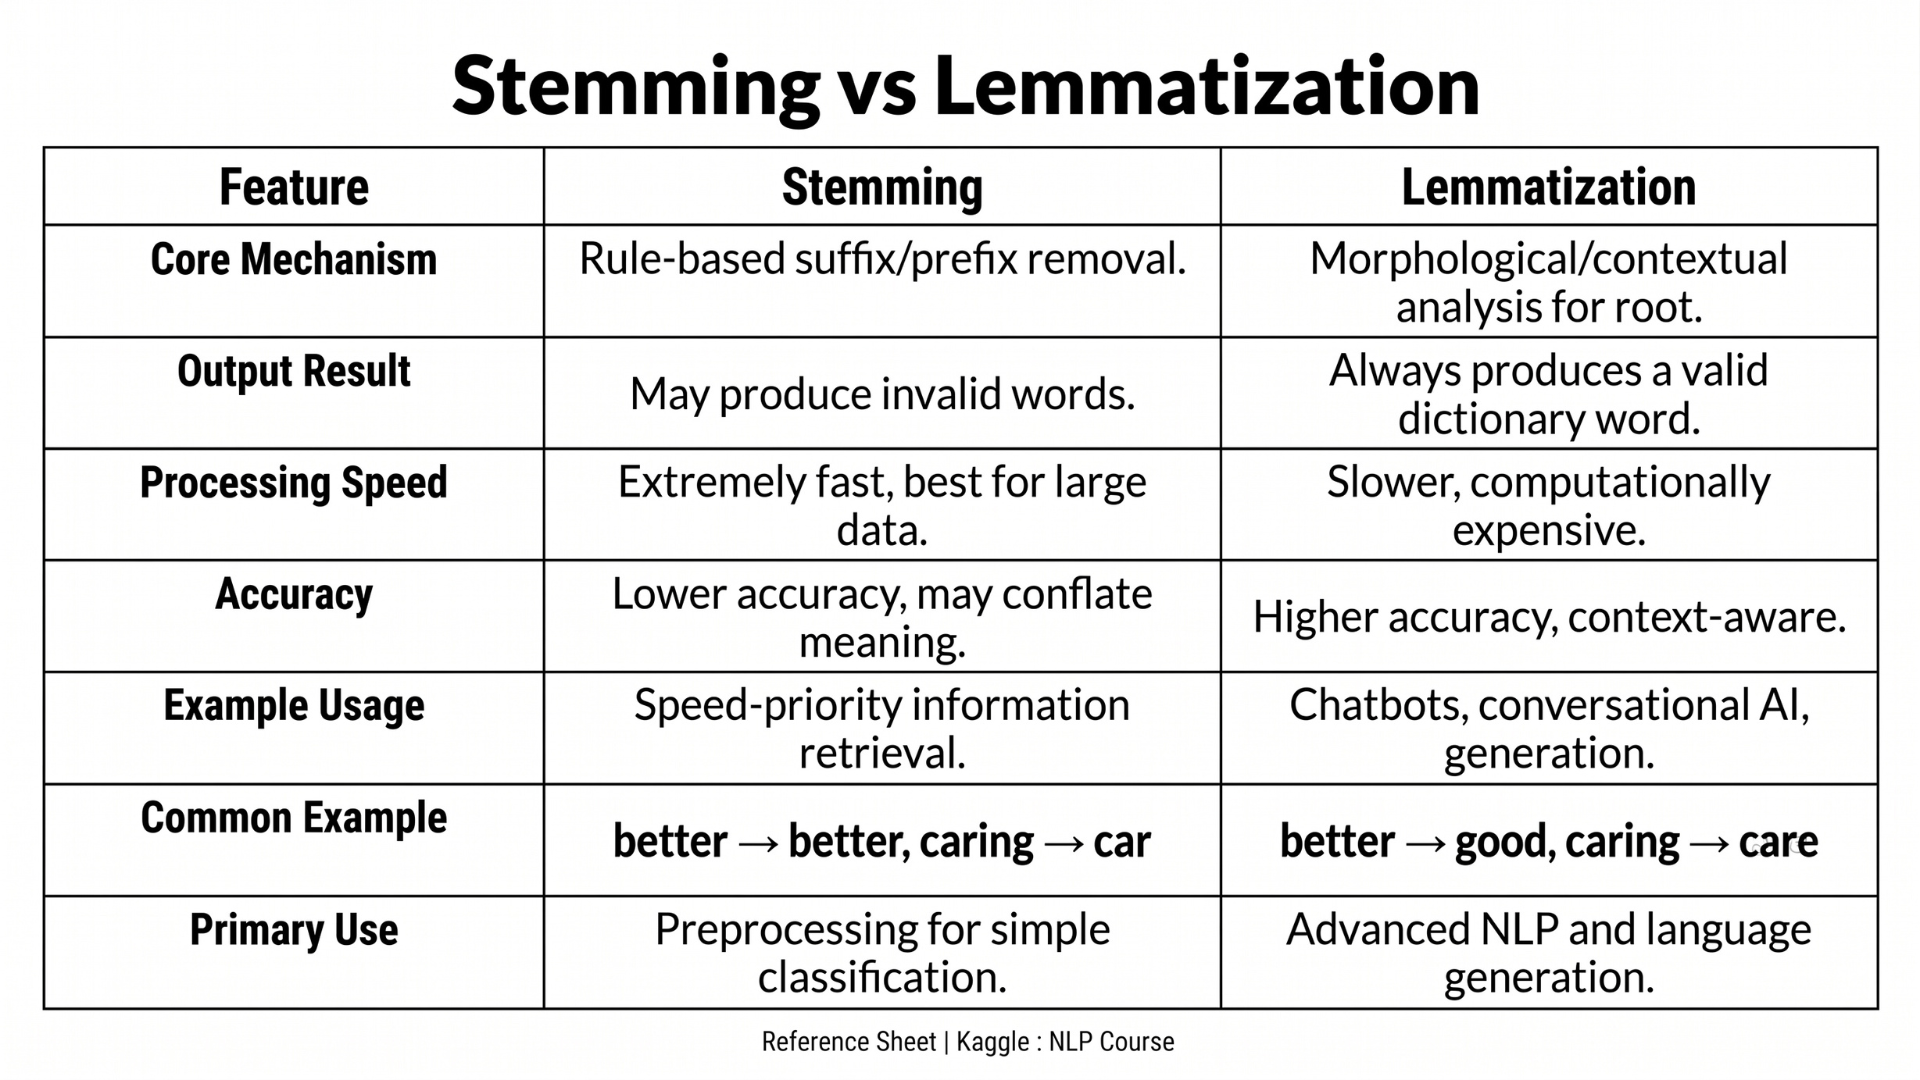

<!-- сюда надо вставить картинку -->

Для стемминга можно использовать библиотеку `nltk`.

In [34]:
from nltk.stem.snowball import SnowballStemmer

Пример работы для английского языка

In [35]:
stemmerEng = SnowballStemmer("english")

for word in ["player", "played", "playing"]:
    print(stemmerEng.stem(word))

player
play
play


Пример работы для русского языка

In [36]:
stemmerRus = SnowballStemmer("russian")

for word in ["игрок", "играли", "играть", "играющий"]:
    print(stemmerRus.stem(word))

игрок
игра
игра
игра


### Named Entity Recognition (NER)

NER – это одна из задач NLP – задача распознавания именованных сущностей (например, имен или названий городов).

В самом простом виде NER-ы умеет находить `pymorphy`, так как в разборах есть такие теги как
- `Geox`

In [37]:
print(morph.parse('Санкт-Петербург'))
print(morph.parse('Москва'))

[Parse(word='санкт-петербург', tag=OpencorporaTag('NOUN,inan,masc,Geox sing,nomn'), normal_form='санкт-петербург', score=0.615384, methods_stack=((DictionaryAnalyzer(), 'санкт-петербург', 74, 0),)), Parse(word='санкт-петербург', tag=OpencorporaTag('NOUN,inan,masc,Geox sing,accs'), normal_form='санкт-петербург', score=0.384615, methods_stack=((DictionaryAnalyzer(), 'санкт-петербург', 74, 3),))]
[Parse(word='москва', tag=OpencorporaTag('NOUN,inan,femn,Sgtm,Geox sing,nomn'), normal_form='москва', score=1.0, methods_stack=((DictionaryAnalyzer(), 'москва', 36, 0),))]


- `Surn`

In [38]:
print(morph.parse('Набоков'))
print(morph.parse('Чичиков'))

[Parse(word='набоков', tag=OpencorporaTag('NOUN,anim,masc,Sgtm,Surn sing,nomn'), normal_form='набоков', score=1.0, methods_stack=((DictionaryAnalyzer(), 'набоков', 37, 0),))]
[Parse(word='чичиков', tag=OpencorporaTag('NOUN,anim,masc,Sgtm,Surn sing,nomn'), normal_form='чичиков', score=1.0, methods_stack=((DictionaryAnalyzer(), 'чичиков', 37, 0),))]


- `Name`

In [39]:
print(morph.parse('Владимир'))
print(morph.parse('Павел'))

[Parse(word='владимир', tag=OpencorporaTag('NOUN,anim,masc,Name sing,nomn'), normal_form='владимир', score=0.979452, methods_stack=((DictionaryAnalyzer(), 'владимир', 27, 0),)), Parse(word='владимир', tag=OpencorporaTag('NOUN,inan,masc,Geox sing,nomn'), normal_form='владимир', score=0.013698, methods_stack=((DictionaryAnalyzer(), 'владимир', 33, 0),)), Parse(word='владимир', tag=OpencorporaTag('NOUN,inan,masc,Geox sing,accs'), normal_form='владимир', score=0.006849, methods_stack=((DictionaryAnalyzer(), 'владимир', 33, 3),))]
[Parse(word='павел', tag=OpencorporaTag('NOUN,anim,masc,Name sing,nomn'), normal_form='павел', score=1.0, methods_stack=((DictionaryAnalyzer(), 'павел', 2370, 0),))]


Для этой задачи есть еще такой проект как `Natasha` (можно почитать [здесь](https://natasha.github.io/)). В нем тоже есть средства для сегментации текстов, морфологического и синтаксического анализа входящих в них токенов и т.д.

Библиотека `spaCy` так же дает возможность поработать с NER.